In [13]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 2000

ages = np.random.randint(18, 65, rows)
browsing_history = np.random.randint(1, 30, rows)
cart_value = np.random.randint(10, 500, rows)
visit_duration = np.random.randint(1, 40, rows)

categories = [
    'Electronics',
    'Fashion',
    'Books',
    'Home',
    'Sports',
    'Beauty'
]

category_viewed = np.random.choice(categories, rows)

purchase = []

for i in range(rows):

    score = 0

    if cart_value[i] > 150:
        score += 1

    if browsing_history[i] > 15:
        score += 1

    if visit_duration[i] > 15:
        score += 1

    purchase.append(1 if score >= 2 else 0)

df = pd.DataFrame({
    'age': ages,
    'browsing_history': browsing_history,
    'cart_value': cart_value,
    'category_viewed': category_viewed,
    'visit_duration': visit_duration,
    'purchase': purchase
})

df.to_csv('ecommerce_dataset.csv', index=False)

print("Dataset Created")

Dataset Created


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pickle

df = pd.read_csv('ecommerce_dataset.csv')

df.head()

,age,browsing_history,cart_value,category_viewed,visit_duration,purchase
0,56,17,56,Electronics,11,0
1,46,27,149,Home,34,1
2,32,25,255,Sports,7,1
3,60,25,158,Beauty,34,1
4,25,28,255,Home,20,1


In [5]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               2000 non-null   int64 
 1   browsing_history  2000 non-null   int64 
 2   cart_value        2000 non-null   int64 
 3   category_viewed   2000 non-null   object
 4   visit_duration    2000 non-null   int64 
 5   purchase          2000 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 93.9+ KB


age                 0
browsing_history    0
cart_value          0
category_viewed     0
visit_duration      0
purchase            0
dtype: int64

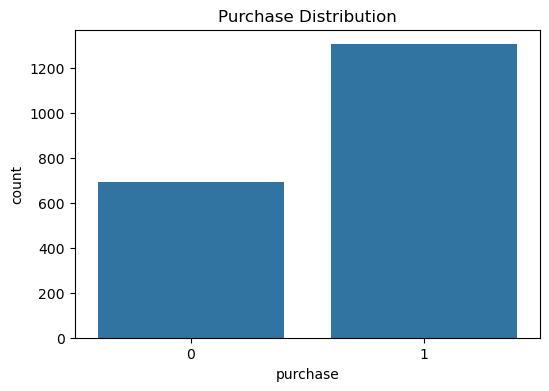

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='purchase',
    data=df
)

plt.title("Purchase Distribution")

plt.show()

In [7]:
encoder = LabelEncoder()

df['category_viewed'] = encoder.fit_transform(
    df['category_viewed']
)

df.head()

,age,browsing_history,cart_value,category_viewed,visit_duration,purchase
0,56,17,56,2,11,0
1,46,27,149,4,34,1
2,32,25,255,5,7,1
3,60,25,158,0,34,1
4,25,28,255,4,20,1


In [8]:
X = df.drop(
    'purchase',
    axis=1
)

y = df['purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [10]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            dt_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        )
    ],

    'Precision': [

        precision_score(
            y_test,
            lr_pred
        ),

        precision_score(
            y_test,
            dt_pred
        ),

        precision_score(
            y_test,
            rf_pred
        )
    ],

    'Recall': [

        recall_score(
            y_test,
            lr_pred
        ),

        recall_score(
            y_test,
            dt_pred
        ),

        recall_score(
            y_test,
            rf_pred
        )
    ],

    'F1 Score': [

        f1_score(
            y_test,
            lr_pred
        ),

        f1_score(
            y_test,
            dt_pred
        ),

        f1_score(
            y_test,
            rf_pred
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.865,0.890511,0.910448,0.900369
1,Decision Tree,1.000,1.000000,1.000000,1.000000
2,Random Forest,1.000,1.000000,1.000000,1.000000


In [12]:
pickle.dump(
    rf,
    open(
        'purchase_model.pkl',
        'wb'
    )
)

print("Model Saved")

Model Saved
